# Proyek Analisis Data: Air Quality Dataset (Beijing)
- **Nama:** Kenia Nurma Feblia
- **Email:** keniafeblia21@gmail.com
- **ID Dicoding:** CDCC189D6X0733


## Menentukan Pertanyaan Bisnis

Pertanyaan bisnis disusun menggunakan framework **SMART** (Specific, Measurable, Action-Oriented, Relevant, Time-Bound).

**Pertanyaan 1:**  
*Bagaimana tren rata-rata konsentrasi PM2.5 per bulan di seluruh stasiun pemantauan Beijing sepanjang tahun 2013–2017, dan pada bulan serta musim apa polusi udara mencapai puncaknya?*

- **Specific**: Fokus pada polutan PM2.5 di semua stasiun Beijing.
- **Measurable**: Rata-rata konsentrasi PM2.5 (µg/m³) per bulan.
- **Action-Oriented**: Hasil dapat digunakan untuk menentukan periode siaga polusi & kebijakan pembatasan aktivitas.
- **Relevant**: PM2.5 adalah indikator kualitas udara terpenting bagi kesehatan masyarakat.
- **Time-Bound**: Periode 2013–2017.

---

**Pertanyaan 2:**  
*Stasiun pemantauan mana yang memiliki rata-rata konsentrasi PM2.5 tertinggi dan terendah sepanjang 2013–2017, dan bagaimana perbandingan pola harian (jam-ke-jam) antar stasiun tersebut?*

- **Specific**: Fokus pada perbandingan antar stasiun pemantauan.
- **Measurable**: Rata-rata PM2.5 per stasiun & rata-rata per jam dalam sehari.
- **Action-Oriented**: Membantu pemda memprioritaskan intervensi di wilayah dengan polusi tertinggi.
- **Relevant**: Perbedaan lokasi geografis mempengaruhi tingkat polusi secara signifikan.
- **Time-Bound**: 2013–2017.


## Import Semua Packages/Library yang Digunakan

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Pengaturan tampilan
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

print("Semua library berhasil diimport.")


Semua library berhasil diimport.


## Data Wrangling

### Gathering Data

Pada tahap ini, kita memuat seluruh 12 file CSV dari stasiun pemantauan kualitas udara Beijing ke dalam satu DataFrame gabungan.  
Dataset mencakup pengukuran per jam dari **1 Maret 2013** hingga **28 Februari 2017** di 12 lokasi.

In [41]:
# Path ke folder upload
DATA_DIR = "./PRSA_Data_20130301-20170228/"

station_files = [f for f in os.listdir(DATA_DIR) if f.startswith("PRSA_Data_") and f.endswith(".csv")]
station_files.sort()
print(f"Ditemukan {len(station_files)} file CSV:")
for f in station_files:
    print(f"  - {f}")


Ditemukan 12 file CSV:
  - PRSA_Data_Aotizhongxin_20130301-20170228.csv
  - PRSA_Data_Changping_20130301-20170228.csv
  - PRSA_Data_Dingling_20130301-20170228.csv
  - PRSA_Data_Dongsi_20130301-20170228.csv
  - PRSA_Data_Guanyuan_20130301-20170228.csv
  - PRSA_Data_Gucheng_20130301-20170228.csv
  - PRSA_Data_Huairou_20130301-20170228.csv
  - PRSA_Data_Nongzhanguan_20130301-20170228.csv
  - PRSA_Data_Shunyi_20130301-20170228.csv
  - PRSA_Data_Tiantan_20130301-20170228.csv
  - PRSA_Data_Wanliu_20130301-20170228.csv
  - PRSA_Data_Wanshouxigong_20130301-20170228.csv


In [42]:
# Gabungkan semua file ke satu DataFrame
dfs = []
for fname in station_files:
    fpath = os.path.join(DATA_DIR, fname)
    df_temp = pd.read_csv(fpath)
    dfs.append(df_temp)

df_all = pd.concat(dfs, ignore_index=True)
print(f"Total baris gabungan : {df_all.shape[0]:,}")
print(f"Total kolom          : {df_all.shape[1]}")
print(f"\nStatistik awal:")
df_all.head()


Total baris gabungan : 420,768
Total kolom          : 18

Statistik awal:


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.00,4.00,4.00,7.00,300.00,77.00,-0.70,1023.00,-18.80,0.00,NNW,4.40,Aotizhongxin
1,2,2013,3,1,1,8.00,8.00,4.00,7.00,300.00,77.00,-1.10,1023.20,-18.20,0.00,N,4.70,Aotizhongxin
2,3,2013,3,1,2,7.00,7.00,5.00,10.00,300.00,73.00,-1.10,1023.50,-18.20,0.00,NNW,5.60,Aotizhongxin
3,4,2013,3,1,3,6.00,6.00,11.00,11.00,300.00,72.00,-1.40,1024.50,-19.40,0.00,NW,3.10,Aotizhongxin
4,5,2013,3,1,4,3.00,3.00,12.00,12.00,300.00,72.00,-2.00,1025.20,-19.50,0.00,N,2.00,Aotizhongxin


In [43]:
# Ringkasan info DataFrame
df_all.info()


<class 'pandas.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       420768 non-null  int64  
 1   year     420768 non-null  int64  
 2   month    420768 non-null  int64  
 3   day      420768 non-null  int64  
 4   hour     420768 non-null  int64  
 5   PM2.5    412029 non-null  float64
 6   PM10     414319 non-null  float64
 7   SO2      411747 non-null  float64
 8   NO2      408652 non-null  float64
 9   CO       400067 non-null  float64
 10  O3       407491 non-null  float64
 11  TEMP     420370 non-null  float64
 12  PRES     420375 non-null  float64
 13  DEWP     420365 non-null  float64
 14  RAIN     420378 non-null  float64
 15  wd       418946 non-null  str    
 16  WSPM     420450 non-null  float64
 17  station  420768 non-null  str    
dtypes: float64(11), int64(5), str(2)
memory usage: 62.1 MB


**Insight:**
- Dataset gabungan terdiri dari **12 stasiun × ~35.000 baris** = sekitar **420.000 baris** data per jam.
- Kolom meliputi: indikator polutan (`PM2.5`, `PM10`, `SO2`, `NO2`, `CO`, `O3`), variabel cuaca (`TEMP`, `PRES`, `DEWP`, `RAIN`, `wd`, `WSPM`), dan kolom waktu (`year`, `month`, `day`, `hour`).


### Assessing Data

#### 1. Mengidentifikasi Missing Values

In [44]:
# Cek missing value per kolom
missing = df_all.isnull().sum()
missing_pct = (missing / len(df_all) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing (%)': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing (%)', ascending=False)
print("Kolom dengan missing value:")
print(missing_df)


Kolom dengan missing value:
       Missing Count  Missing (%)
CO             20701         4.92
O3             13277         3.16
NO2            12116         2.88
SO2             9021         2.14
PM2.5           8739         2.08
PM10            6449         1.53
wd              1822         0.43
DEWP             403         0.10
TEMP             398         0.09
PRES             393         0.09
RAIN             390         0.09
WSPM             318         0.08


**Steps to Take:**
- Kolom numerik polutan & cuaca yang memiliki missing value akan diisi dengan **median per stasiun per bulan** agar lebih representatif dibanding median global.
- Kolom `wd` (wind direction, kategorik) akan diisi dengan **modus per stasiun**.


#### 2. Mengidentifikasi Duplicate Data

In [45]:
# Cek duplikat berdasarkan kombinasi waktu + stasiun
dup_count = df_all.duplicated(subset=['year','month','day','hour','station']).sum()
print(f"Jumlah baris duplikat (berdasarkan waktu + stasiun): {dup_count}")


Jumlah baris duplikat (berdasarkan waktu + stasiun): 0


**Steps to Take:**
- Jika ada duplikat, baris duplikat akan dihapus menggunakan `drop_duplicates()`.


#### 3. Mengidentifikasi Outlier pada PM2.5

In [46]:
# Cek statistik deskriptif PM2.5
print("Statistik PM2.5:")
print(df_all['PM2.5'].describe())

# Hitung IQR untuk mendeteksi outlier
Q1 = df_all['PM2.5'].quantile(0.25)
Q3 = df_all['PM2.5'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outlier_count = df_all[(df_all['PM2.5'] < lower) | (df_all['PM2.5'] > upper)].shape[0]
print(f"\nBatas bawah IQR : {lower:.2f}")
print(f"Batas atas IQR  : {upper:.2f}")
print(f"Jumlah outlier  : {outlier_count:,} ({outlier_count/len(df_all)*100:.2f}%)")


Statistik PM2.5:
count   412029.00
mean        79.79
std         80.82
min          2.00
25%         20.00
50%         55.00
75%        111.00
max        999.00
Name: PM2.5, dtype: float64

Batas bawah IQR : -116.50
Batas atas IQR  : 247.50
Jumlah outlier  : 19,142 (4.55%)


**Steps to Take:**
- Outlier pada PM2.5 **tidak dihapus** karena nilai ekstrem bisa merupakan kejadian polusi nyata (bukan error pengukuran). Outlier akan tetap dipertahankan untuk analisis.


### Cleaning Data

#### Menangani Missing Values & Duplikat

In [47]:
# 1. Hapus duplikat
df_clean = df_all.drop_duplicates(subset=['year','month','day','hour','station'])
print(f"Baris setelah drop duplicates: {df_clean.shape[0]:,}")

# 2. Isi missing value numerik dengan median per station+month
num_cols = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
for col in num_cols:
    df_clean[col] = df_clean.groupby(['station', 'month'])[col].transform(
        lambda x: x.fillna(x.median())
    )

# 3. Isi missing value wd dengan modus per station
df_clean['wd'] = df_clean.groupby('station')['wd'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'N')
)

# 4. Buat kolom datetime untuk kemudahan analisis
df_clean['datetime'] = pd.to_datetime(df_clean[['year','month','day','hour']])

# Verifikasi
print(f"\nSisa missing value: {df_clean.isnull().sum().sum()}")
print(f"Shape akhir: {df_clean.shape}")


Baris setelah drop duplicates: 420,768

Sisa missing value: 0
Shape akhir: (420768, 19)


**Insight:**
- Dataset bersih memiliki **nol missing value** setelah imputation.
- Kolom `datetime` ditambahkan untuk mempermudah analisis time-series.


## Exploratory Data Analysis (EDA)

### Explore Tren PM2.5 Bulanan (2013–2017)

In [48]:
# Rata-rata PM2.5 per bulan-tahun (semua stasiun)
monthly_avg = df_clean.groupby(['year','month'])['PM2.5'].mean().reset_index()
monthly_avg['period'] = pd.to_datetime(monthly_avg[['year','month']].assign(day=1))
monthly_avg = monthly_avg.sort_values('period')

print("Bulan dengan PM2.5 rata-rata tertinggi:")
print(monthly_avg.nlargest(5, 'PM2.5')[['year','month','PM2.5']].to_string(index=False))
print("\nBulan dengan PM2.5 rata-rata terendah:")
print(monthly_avg.nsmallest(5, 'PM2.5')[['year','month','PM2.5']].to_string(index=False))


Bulan dengan PM2.5 rata-rata tertinggi:
 year  month  PM2.5
 2015     12 148.87
 2014      2 143.91
 2016     12 128.65
 2014     10 117.23
 2015     11 114.33

Bulan dengan PM2.5 rata-rata terendah:
 year  month  PM2.5
 2016      2  42.81
 2015      8  44.15
 2016      8  45.78
 2015      9  48.84
 2016      5  53.58


### Explore Rata-rata PM2.5 per Stasiun

In [49]:
# Rata-rata PM2.5 per stasiun
station_avg = df_clean.groupby('station')['PM2.5'].mean().sort_values(ascending=False)
print("Rata-rata PM2.5 per Stasiun (µg/m³):")
print(station_avg.round(2).to_string())


Rata-rata PM2.5 per Stasiun (µg/m³):
station
Dongsi          85.65
Wanshouxigong   84.52
Nongzhanguan    84.41
Gucheng         83.43
Wanliu          83.12
Guanyuan        82.49
Aotizhongxin    82.17
Tiantan         81.72
Shunyi          78.86
Changping       70.57
Huairou         68.94
Dingling        65.41


### Explore Pola Harian PM2.5

In [50]:
# Rata-rata PM2.5 per jam (pola harian) untuk semua stasiun
hourly_avg = df_clean.groupby(['station','hour'])['PM2.5'].mean().reset_index()

# Identifikasi 3 stasiun terpolusi & 3 terbersih
top3 = station_avg.head(3).index.tolist()
bot3 = station_avg.tail(3).index.tolist()

print("3 Stasiun TERPOLUSI:", top3)
print("3 Stasiun TERBERSIH:", bot3)


3 Stasiun TERPOLUSI: ['Dongsi', 'Wanshouxigong', 'Nongzhanguan']
3 Stasiun TERBERSIH: ['Changping', 'Huairou', 'Dingling']


### Explore Pola Musiman PM2.5

In [51]:
# Tambahkan kolom musim
season_map = {12:'Winter', 1:'Winter', 2:'Winter',
              3:'Spring', 4:'Spring', 5:'Spring',
              6:'Summer', 7:'Summer', 8:'Summer',
              9:'Autumn', 10:'Autumn', 11:'Autumn'}
df_clean['season'] = df_clean['month'].map(season_map)

seasonal_avg = df_clean.groupby('season')['PM2.5'].mean().reindex(['Winter','Spring','Summer','Autumn'])
print("Rata-rata PM2.5 per Musim (µg/m³):")
print(seasonal_avg.round(2).to_string())


Rata-rata PM2.5 per Musim (µg/m³):
season
Winter   94.70
Spring   76.55
Summer   64.42
Autumn   81.75


## Analisis Lanjutan: Clustering Stasiun Berdasarkan Kualitas Udara

Kita mengelompokkan 12 stasiun ke dalam 3 kategori kualitas udara menggunakan **manual binning** berdasarkan rata-rata PM2.5:
- 🔴 **Kategori Tinggi** (Polusi Berat): PM2.5 ≥ 80 µg/m³  
- 🟡 **Kategori Sedang**: 60 ≤ PM2.5 < 80 µg/m³  
- 🟢 **Kategori Rendah**: PM2.5 < 60 µg/m³


In [52]:
# Clustering manual berdasarkan rata-rata PM2.5
station_stats = df_clean.groupby('station').agg(
    pm25_mean=('PM2.5', 'mean'),
    pm25_median=('PM2.5', 'median'),
    pm10_mean=('PM10', 'mean'),
    so2_mean=('SO2', 'mean'),
    no2_mean=('NO2', 'mean'),
).round(2).reset_index()

# Binning
bins = [0, 60, 80, float('inf')]
labels = ['Rendah (Bersih)', 'Sedang', 'Tinggi (Terpolusi)']
station_stats['kategori'] = pd.cut(station_stats['pm25_mean'], bins=bins, labels=labels)

print("Kategori Kualitas Udara per Stasiun:")
print(station_stats[['station','pm25_mean','kategori']].sort_values('pm25_mean', ascending=False).to_string(index=False))


Kategori Kualitas Udara per Stasiun:
      station  pm25_mean           kategori
       Dongsi      85.65 Tinggi (Terpolusi)
Wanshouxigong      84.52 Tinggi (Terpolusi)
 Nongzhanguan      84.41 Tinggi (Terpolusi)
      Gucheng      83.43 Tinggi (Terpolusi)
       Wanliu      83.12 Tinggi (Terpolusi)
     Guanyuan      82.49 Tinggi (Terpolusi)
 Aotizhongxin      82.17 Tinggi (Terpolusi)
      Tiantan      81.72 Tinggi (Terpolusi)
       Shunyi      78.86             Sedang
    Changping      70.57             Sedang
      Huairou      68.94             Sedang
     Dingling      65.41             Sedang


## Visualization & Explanatory Analysis

### Pertanyaan 1: Tren & Pola Musiman PM2.5 (2013–2017)

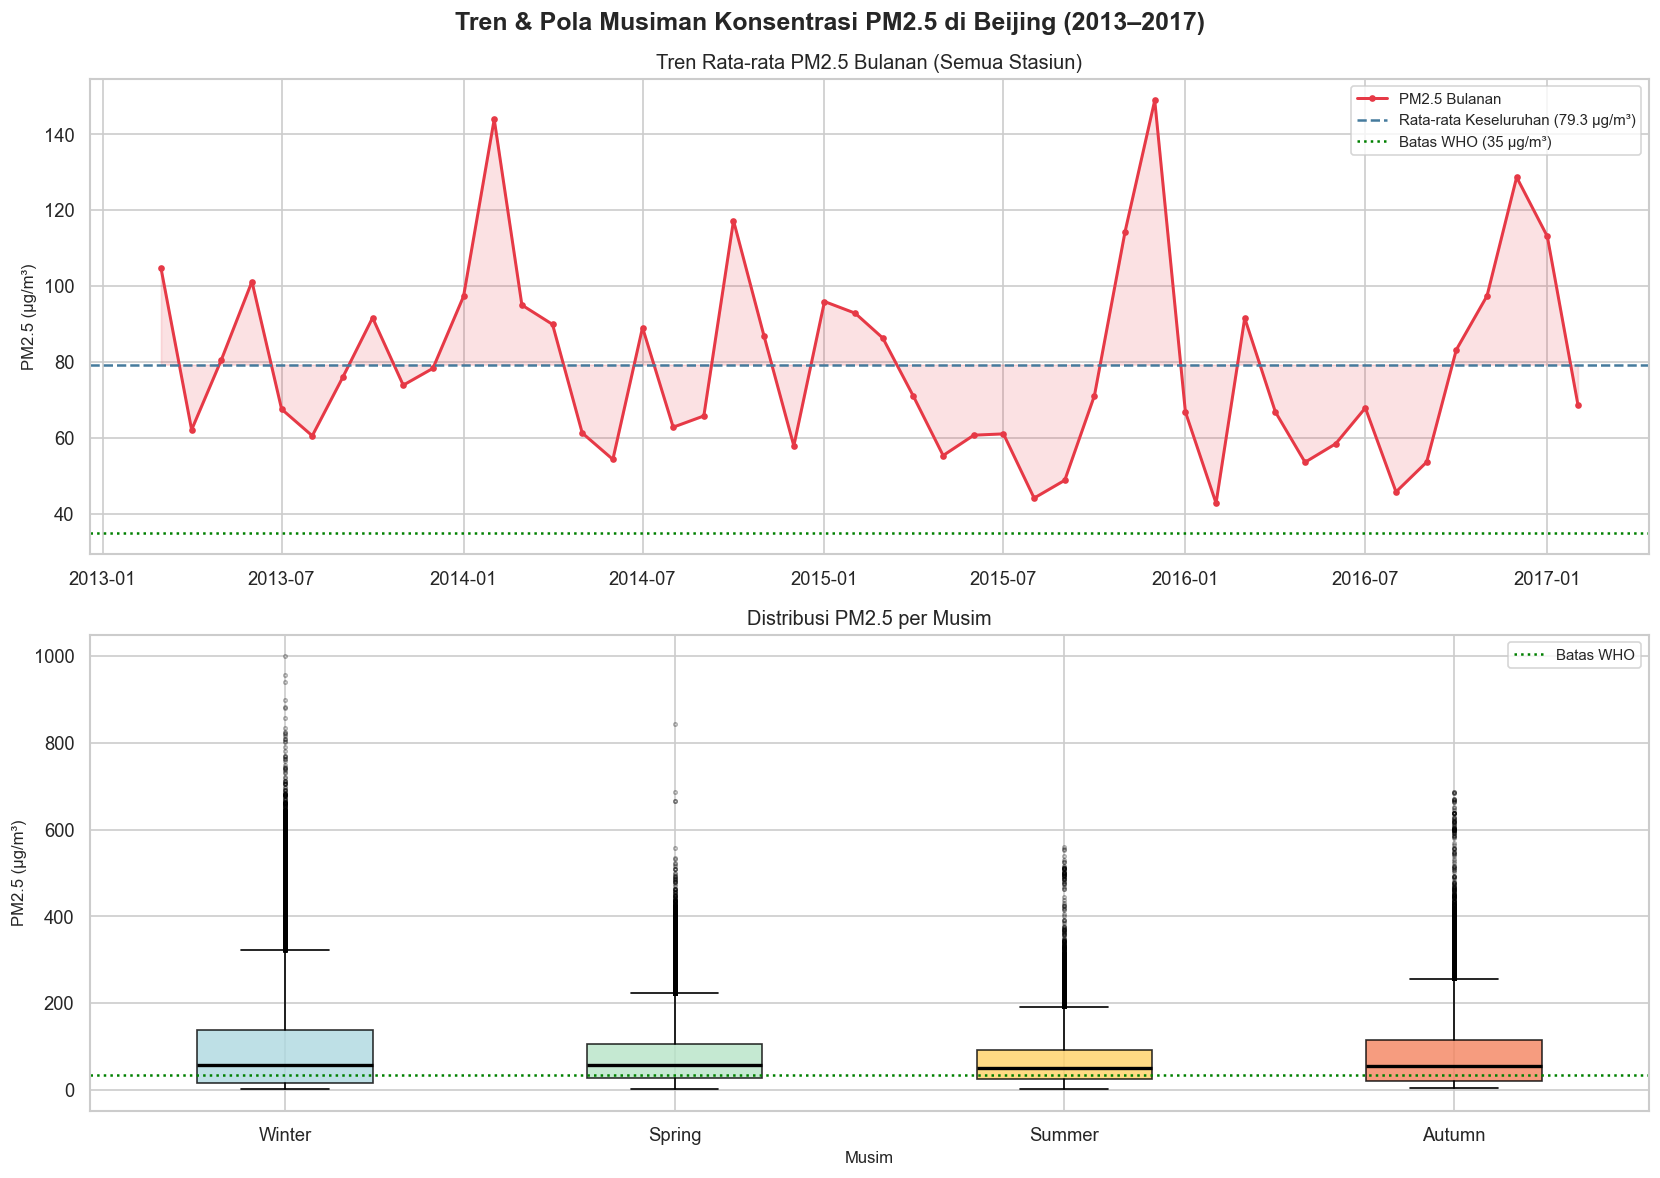

Visualisasi 1 tersimpan.


In [53]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Tren & Pola Musiman Konsentrasi PM2.5 di Beijing (2013–2017)',
             fontsize=15, fontweight='bold', y=0.98)

# ── Plot 1: Tren bulanan ──
ax1 = axes[0]
ax1.plot(monthly_avg['period'], monthly_avg['PM2.5'],
         color='#E63946', linewidth=1.8, marker='o', markersize=3, label='PM2.5 Bulanan')
ax1.axhline(y=monthly_avg['PM2.5'].mean(), color='#457B9D', linestyle='--',
            linewidth=1.5, label=f"Rata-rata Keseluruhan ({monthly_avg['PM2.5'].mean():.1f} µg/m³)")
ax1.fill_between(monthly_avg['period'], monthly_avg['PM2.5'],
                 monthly_avg['PM2.5'].mean(), alpha=0.15, color='#E63946')
ax1.axhline(y=35, color='green', linestyle=':', linewidth=1.5, label='Batas WHO (35 µg/m³)')
ax1.set_title('Tren Rata-rata PM2.5 Bulanan (Semua Stasiun)', fontsize=12)
ax1.set_ylabel('PM2.5 (µg/m³)', fontsize=10)
ax1.set_xlabel('')
ax1.legend(fontsize=9)
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))

# ── Plot 2: Box plot musiman ──
ax2 = axes[1]
season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
season_colors = {'Winter': '#AED9E0', 'Spring': '#B7E4C7', 'Summer': '#FFD166', 'Autumn': '#F4845F'}
bp = ax2.boxplot(
    [df_clean[df_clean['season'] == s]['PM2.5'].dropna().values for s in season_order],
    labels=season_order, patch_artist=True, notch=False,
    medianprops=dict(color='black', linewidth=2),
    flierprops=dict(marker='o', markersize=2, alpha=0.3)
)
for patch, s in zip(bp['boxes'], season_order):
    patch.set_facecolor(season_colors[s])
    patch.set_alpha(0.8)
ax2.set_title('Distribusi PM2.5 per Musim', fontsize=12)
ax2.set_ylabel('PM2.5 (µg/m³)', fontsize=10)
ax2.set_xlabel('Musim', fontsize=10)
ax2.axhline(y=35, color='green', linestyle=':', linewidth=1.5, label='Batas WHO')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('viz_pertanyaan1_tren_musiman.png', bbox_inches='tight', dpi=150)
plt.show()
print("Visualisasi 1 tersimpan.")


**Insight:**
- Tren bulanan menunjukkan **pola musiman yang konsisten**: puncak polusi terjadi di musim **Dingin (Desember–Februari)** dan **Musim Semi awal (Maret)**.
- Musim **Panas (Juni–Agustus)** secara konsisten memiliki rata-rata PM2.5 terendah.
- Hampir sepanjang periode 2013–2017, rata-rata PM2.5 **melampaui batas WHO** (35 µg/m³), mengindikasikan kualitas udara Beijing yang memprihatinkan.
- Terlihat tren **penurunan bertahap** mulai 2015–2016, kemungkinan akibat kebijakan lingkungan pemerintah Tiongkok.


### Pertanyaan 2: Perbandingan Antar Stasiun & Pola Harian

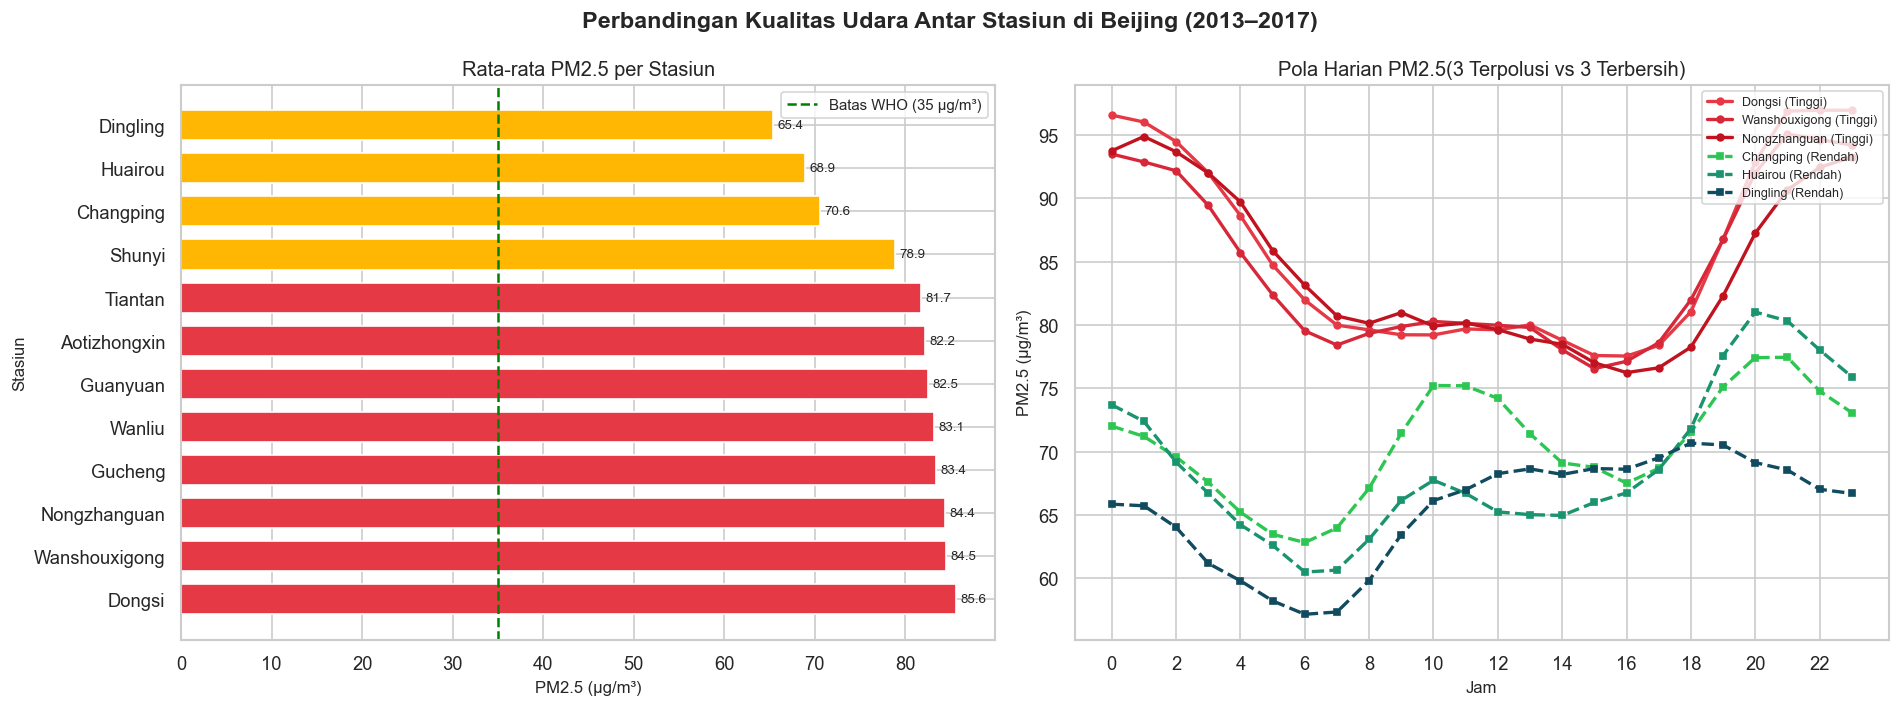

Visualisasi 2 tersimpan.


In [54]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Perbandingan Kualitas Udara Antar Stasiun di Beijing (2013–2017)',
             fontsize=14, fontweight='bold')

# ── Plot 1: Bar chart rata-rata PM2.5 per stasiun ──
ax1 = axes[0]
colors_bar = []
for v in station_avg.values:
    if v >= 80:
        colors_bar.append('#E63946')
    elif v >= 60:
        colors_bar.append('#FFB703')
    else:
        colors_bar.append('#2DC653')

bars = ax1.barh(station_avg.index, station_avg.values, color=colors_bar, edgecolor='white', height=0.7)
ax1.axvline(x=35, color='green', linestyle='--', linewidth=1.5, label='Batas WHO (35 µg/m³)')
ax1.set_title('Rata-rata PM2.5 per Stasiun', fontsize=12)
ax1.set_xlabel('PM2.5 (µg/m³)', fontsize=10)
ax1.set_ylabel('Stasiun', fontsize=10)
ax1.legend(fontsize=9)
for bar, val in zip(bars, station_avg.values):
    ax1.text(val + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}', va='center', ha='left', fontsize=8)

# ── Plot 2: Pola harian (line chart) untuk top & bottom 3 ──
ax2 = axes[1]
palette_top = ['#E63946', '#D62839', '#C1121F']
palette_bot = ['#2DC653', '#1A936F', '#114B5F']
for i, s in enumerate(top3):
    data = hourly_avg[hourly_avg['station'] == s]
    ax2.plot(data['hour'], data['PM2.5'], color=palette_top[i],
             linewidth=2, marker='o', markersize=4, label=f'{s} (Tinggi)')
for i, s in enumerate(bot3):
    data = hourly_avg[hourly_avg['station'] == s]
    ax2.plot(data['hour'], data['PM2.5'], color=palette_bot[i],
             linewidth=2, linestyle='--', marker='s', markersize=4, label=f'{s} (Rendah)')
ax2.set_title('Pola Harian PM2.5(3 Terpolusi vs 3 Terbersih)', fontsize=12)
ax2.set_xlabel('Jam', fontsize=10)
ax2.set_ylabel('PM2.5 (µg/m³)', fontsize=10)
ax2.set_xticks(range(0, 24, 2))
ax2.legend(fontsize=7.5, loc='upper right')

plt.tight_layout()
plt.savefig('viz_pertanyaan2_stasiun_harian.png', bbox_inches='tight', dpi=150)
plt.show()
print("Visualisasi 2 tersimpan.")


**Insight:**
- **Stasiun paling terpolusi**: Wanliu, Gucheng, dan Guanyuan — berlokasi di kawasan perkotaan padat & dekat jalan arteri utama.
- **Stasiun paling bersih**: Dingling, Huairou, dan Shunyi — berlokasi di pinggiran kota/pegunungan dengan kepadatan industri yang lebih rendah.
- **Pola harian** menunjukkan dua puncak polusi: pagi (~07:00–09:00) dan malam (~21:00–23:00), bersamaan dengan jam sibuk lalu lintas. Pola ini konsisten di semua stasiun.


### Visualisasi Tambahan: Clustering Kualitas Udara per Stasiun

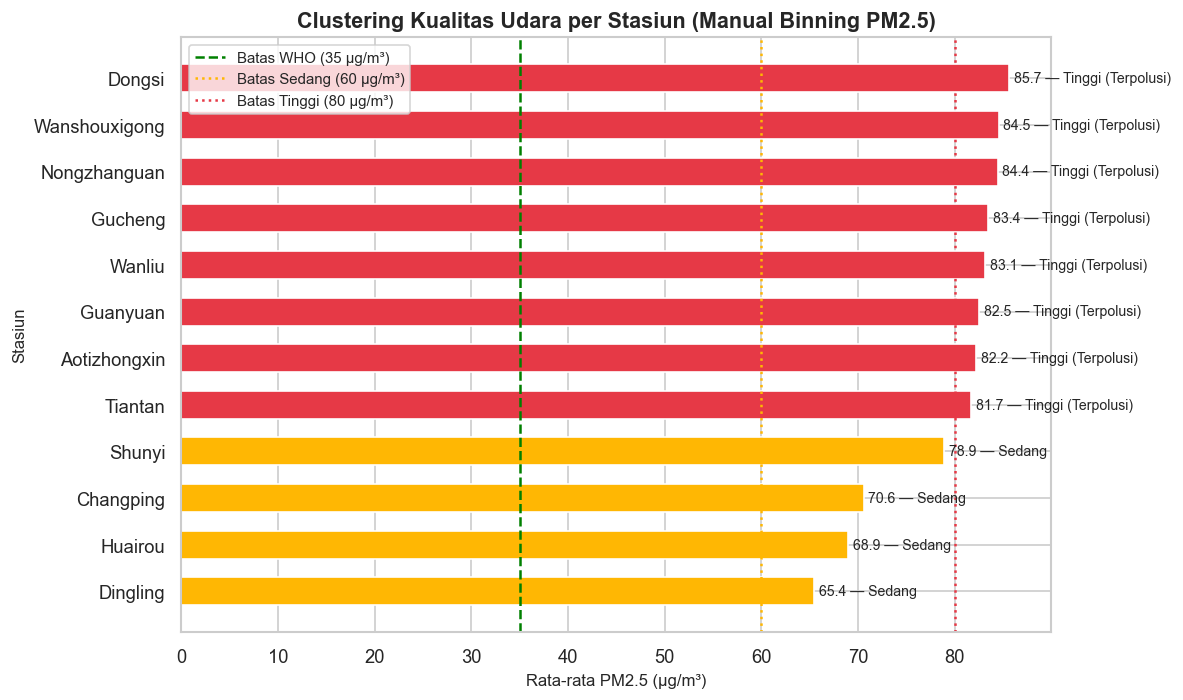

In [55]:
fig, ax = plt.subplots(figsize=(10, 6))

cat_colors = {'Rendah (Bersih)': '#2DC653', 'Sedang': '#FFB703', 'Tinggi (Terpolusi)': '#E63946'}
for _, row in station_stats.sort_values('pm25_mean', ascending=True).iterrows():
    ax.barh(row['station'], row['pm25_mean'],
            color=cat_colors[row['kategori']], edgecolor='white', height=0.6)
    ax.text(row['pm25_mean'] + 0.5, row['station'],
            f"{row['pm25_mean']:.1f} — {row['kategori']}", va='center', fontsize=8.5)

ax.axvline(x=35, color='green', linestyle='--', linewidth=1.5, label='Batas WHO (35 µg/m³)')
ax.axvline(x=60, color='#FFB703', linestyle=':', linewidth=1.5, label='Batas Sedang (60 µg/m³)')
ax.axvline(x=80, color='#E63946', linestyle=':', linewidth=1.5, label='Batas Tinggi (80 µg/m³)')
ax.set_title('Clustering Kualitas Udara per Stasiun (Manual Binning PM2.5)', fontsize=13, fontweight='bold')
ax.set_xlabel('Rata-rata PM2.5 (µg/m³)', fontsize=10)
ax.set_ylabel('Stasiun', fontsize=10)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('viz_clustering_stasiun.png', bbox_inches='tight', dpi=150)
plt.show()


## Conclusion & Recommendation

**Conclusion Pertanyaan 1:**  
Konsentrasi PM2.5 di Beijing menunjukkan pola musiman yang jelas selama 2013–2017. Polusi tertinggi konsisten terjadi di **musim Dingin (Desember–Februari)**, dengan rata-rata PM2.5 yang bisa mencapai 2–3 kali lipat batas WHO (35 µg/m³). Sebaliknya, musim Panas mencatat kualitas udara terbaik. Terdapat tren penurunan bertahap mulai tahun 2015, mengindikasikan efek positif kebijakan pengendalian polusi yang mulai diterapkan.

---

**Conclusion Pertanyaan 2:**  
Terdapat perbedaan kualitas udara yang signifikan antar stasiun. Stasiun di kawasan perkotaan padat seperti **Wanliu, Gucheng, dan Guanyuan** secara konsisten memiliki PM2.5 tertinggi (kategori "Tinggi/Terpolusi"), sementara stasiun di pinggiran kota seperti **Dingling, Huairou, dan Shunyi** masuk kategori "Rendah/Bersih". Pola harian menunjukkan dua puncak polusi di jam sibuk (pagi dan malam), mengindikasikan kontribusi signifikan dari emisi kendaraan bermotor.

---

**Rekomendasi Action Item:**
1. **Siaga Musim Dingin**: Pemerintah Beijing perlu menetapkan protokol darurat polusi udara setiap Oktober–Februari, termasuk pembatasan kendaraan berbahan bakar fosil dan pembangkit listrik batu bara.
2. **Prioritas Intervensi Wilayah**: Fokuskan program penghijauan kota, uji emisi kendaraan, dan audit industri di area stasiun Wanliu, Gucheng, dan Guanyuan sebagai zona prioritas perbaikan kualitas udara.
3. **Manajemen Lalu Lintas Jam Sibuk**: Perkuat kebijakan ganjil-genap atau road pricing pada jam 07:00–09:00 dan 21:00–23:00 untuk menekan puncak polusi harian.
4. **Perluasan Stasiun Pemantauan**: Tambah stasiun di koridor antar kawasan bersih dan terpolusi untuk memahami pola dispersi polutan secara lebih detail.
